## Pass vs Fail Classification using Perceptron

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Study hours and Sleep hours for 12 students
X = np.array([
    [2, 5], [3, 4], [1, 6], [4, 5], [2, 8], [3, 6],  # Fail
    [6, 7], [7, 6], [8, 8], [5, 7], [7, 5], [9, 6],  # Pass
])

# Labels: 0 = Fail, 1 = Pass
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

In [2]:
# Bring all values to the same scale
mean = X.mean(axis=0)   # average of each column
std  = X.std(axis=0)    # spread of each column

X_norm = (X - mean) / std

In [3]:
# Start with zero knowledge
w1   = 0.0   # weight for study hours
w2   = 0.0   # weight for sleep hours
bias = 0.0

lr   = 0.1   # learning rate — how big each update step is

In [4]:
# Perceptron Algo
for epoch in range(1000):
    errors = 0

    for i in range(len(X_norm)):

        # Pick one student
        x1 = X_norm[i][0]   # study hours (normalized)
        x2 = X_norm[i][1]   # sleep hours (normalized)

        # Compute weighted sum
        z = w1 * x1 + w2 * x2 + bias

        # Activation — step function
        if z >= 0:
            y_hat = 1   # predict Pass
        else:
            y_hat = 0   # predict Fail

        # Calculate error
        error = y[i] - y_hat

        # Update weights only if wrong
        if error != 0:
            w1   = w1   + lr * error * x1
            w2   = w2   + lr * error * x2
            bias = bias + lr * error
            errors += 1

    # Stop if no mistakes this epoch
    if errors == 0:
        print(f"Converged at epoch {epoch + 1}!")
        break

print(f"w1 = {w1:.4f}, w2 = {w2:.4f}, bias = {bias:.4f}")

Converged at epoch 2!
w1 = 0.1984, w2 = 0.0842, bias = 0.0000


In [5]:
# Compute accuracy of model
correct = 0

for i in range(len(X_norm)):
    x1    = X_norm[i][0]
    x2    = X_norm[i][1]
    z     = w1 * x1 + w2 * x2 + bias
    y_hat = 1 if z >= 0 else 0

    if y_hat == y[i]:
        correct += 1

print(f"Accuracy: {correct}/{len(y)} = {correct/len(y)*100:.0f}%")

Accuracy: 12/12 = 100%


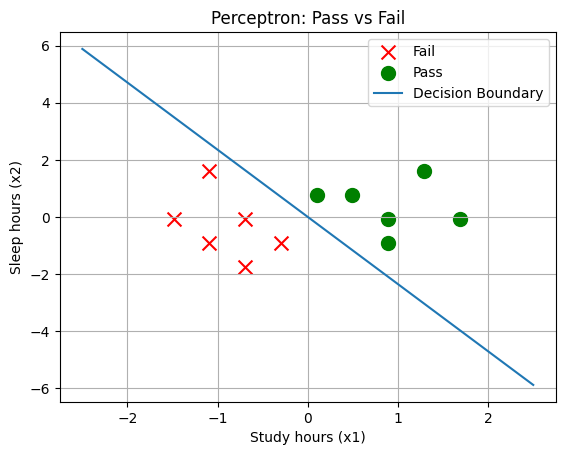

In [ ]:
# Plotting the decision boundary

for i in range(len(X_norm)):
    if y[i]==0:
        plt.scatter(X_norm[i][0],X_norm[i][1], marker='x', color="red",  label='Fail' if i==0 else "")

    else:
        plt.scatter(X_norm[i][0],X_norm[i][1], marker='o', color="green",  label='Pass' if i==6 else "")

# Decision Boundary
x1 = np.linspace(-2.5, 2.5, 200)
x2 = -(w1 * x1 + bias) / w2


plt.plot(x1,x2,label="Decision Boundary")


plt.xlabel("Study hours (x1)")
plt.ylabel("Sleep hours (x2)")
plt.title("Perceptron: Pass vs Fail")
plt.legend()
plt.grid()

plt.show()